In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# pip install pandas numpy matplotlib seaborn scikit-learn geopy joblib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# To avoid warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('Dataset.csv')
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Delivery Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30


In [5]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("(", "")
df.columns = df.columns.str.replace(")", "")
df.columns = df.columns.str.lower()

In [6]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           45593 non-null  object 
 1   delivery_person_id           45593 non-null  object 
 2   delivery_person_age          45593 non-null  int64  
 3   delivery_person_ratings      45593 non-null  float64
 4   restaurant_latitude          45593 non-null  float64
 5   restaurant_longitude         45593 non-null  float64
 6   delivery_location_latitude   45593 non-null  float64
 7   delivery_location_longitude  45593 non-null  float64
 8   type_of_order                45593 non-null  object 
 9   type_of_vehicle              45593 non-null  object 
 10  delivery_time_takenmin       45593 non-null  int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 3.8+ MB


,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,delivery_time_takenmin
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,29.544075,4.632367,17.017729,70.231332,17.465186,70.845702,26.294607
std,5.696793,0.327708,8.185109,22.883647,7.335122,21.118812,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,10.000000
25%,25.000000,4.600000,12.933284,73.170000,12.988453,73.280000,19.000000
50%,29.000000,4.700000,18.546947,75.898497,18.633934,76.002574,26.000000
75%,34.000000,4.800000,22.728163,78.044095,22.785049,78.107044,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,54.000000


In [7]:
# Missing values
df.isnull().sum()

# Drop missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

In [8]:
df.columns

Index(['id', 'delivery_person_id', 'delivery_person_age',
       'delivery_person_ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_location_latitude',
       'delivery_location_longitude', 'type_of_order', 'type_of_vehicle',
       'delivery_time_takenmin'],
      dtype='object')

In [9]:
import numpy as np

lat1 = np.radians(df['restaurant_latitude'])
lon1 = np.radians(df['restaurant_longitude'])
lat2 = np.radians(df['delivery_location_latitude'])
lon2 = np.radians(df['delivery_location_longitude'])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

df['distance'] = 6371 * c

In [10]:
df = df.drop(['id', 'delivery_person_id'], axis=1)

In [11]:
df = pd.get_dummies(df, columns=['type_of_order', 'type_of_vehicle'], drop_first=True)

In [12]:
X = df.drop('delivery_time_takenmin', axis=1)
y = df['delivery_time_takenmin']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=30,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained ✅")

Model trained ✅


In [15]:
from math import radians, sin, cos, sqrt, atan2

def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

In [16]:
df['distance'] = df.apply(lambda row: calculate_distance(
    row['restaurant_latitude'],
    row['restaurant_longitude'],
    row['delivery_location_latitude'],
    row['delivery_location_longitude']
), axis=1)

df.head()

,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,delivery_time_takenmin,distance,type_of_order_Drinks,type_of_order_Meal,type_of_order_Snack,type_of_vehicle_electric_scooter,type_of_vehicle_motorcycle,type_of_vehicle_scooter
0,37,4.9,22.745049,75.892471,22.765049,75.912471,24,3.025149,False,False,True,False,True,False
1,34,4.5,12.913041,77.683237,13.043041,77.813237,33,20.183530,False,False,True,False,False,True
2,23,4.4,12.914264,77.678400,12.924264,77.688400,26,1.552758,True,False,False,False,True,False
3,38,4.7,11.003669,76.976494,11.053669,77.026494,21,7.790401,False,False,False,False,True,False
4,32,4.6,12.972793,80.249982,13.012793,80.289982,30,6.210138,False,False,True,False,False,True


In [17]:
X = df.drop('delivery_time_takenmin', axis=1)
y = df['delivery_time_takenmin']

In [18]:
X = df.drop(columns=['delivery_time_takenmin', 'id', 'delivery_person_id'], errors='ignore')
y = df['delivery_time_takenmin']

In [19]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("(", "")
df.columns = df.columns.str.replace(")", "")

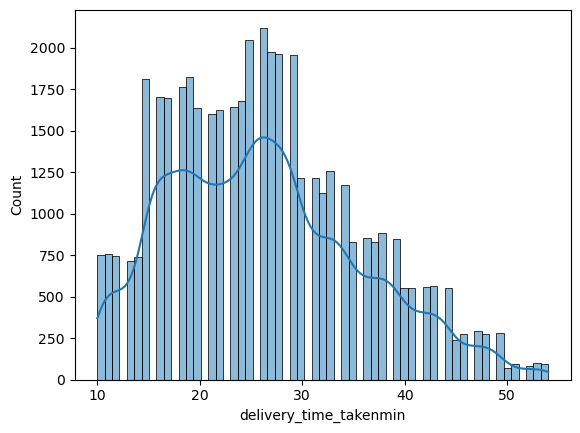

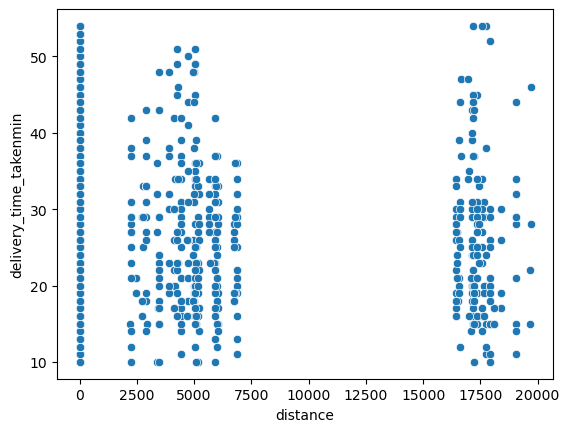

In [20]:
plt.figure()
sns.histplot(df['delivery_time_takenmin'], kde=True)
plt.show()

plt.figure()
sns.scatterplot(x=df['distance'], y=df['delivery_time_takenmin'])
plt.show()

In [21]:
X = df.drop(columns=['delivery_time_takenmin', 'id', 'delivery_person_id'], errors='ignore')
y = df['delivery_time_takenmin']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 6.008240368372839
RMSE: 7.698052461666778


In [25]:
import joblib
joblib.dump(model, 'delivery_model.pkl')

['delivery_model.pkl']

In [26]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_estimators=200, random_state=42)

In [27]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [28]:
from sklearn.metrics import mean_absolute_error

# Random Forest
y_pred_rf = model.predict(X_test)
print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))

# Decision Tree
print("DT MAE:", mean_absolute_error(y_test, y_pred_dt))

RF MAE: 5.775467664743051
DT MAE: 7.990185327338524


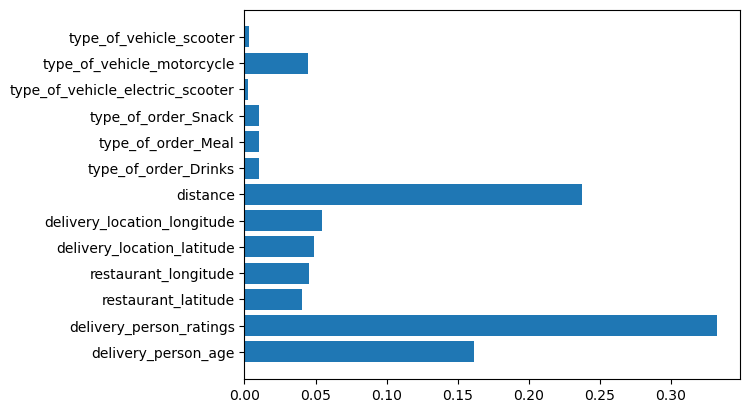

In [29]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importance)
plt.show()